# ADS-509 Assignment 1.1
## Collecting Text Data via API and Web Scraping

**Student Version**  

In this assignment you will:
- Collect story metadata via an API (Hacker News).
- Scrape discussion comments from HTML using BeautifulSoup.
- Merge into one tidy dataset (one row per comment with story metadata).
- Save results and run some quick checks/EDA.

Although the discussion posts are available via the HackerNews API, this mirrors real-world pipelines where structured APIs don’t expose the exact text you need, so you complement them with carefully designed scrapers.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

Work through this notebook as if it were a worksheet, completing the code sections marked with **TODO** in the cells provided. Similarly, written questions will be marked by a "Q:" and will have a corresponding "A:" spot for you to fill in with your answers. **Make sure to answer every question marked with a Q: for full credit**.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential import statements and make sure that all such statements are moved into the designated cell.

A .pdf of this notebook, with your completed code and written answers, is what you should submit in Canvas for full credit. **DO NOT SUBMIT A NEW NOTEBOOK FILE OR A RAW .PY FILE**. Submitting in a different format makes it difficult to grade your work, and students who have done this in the past inevitably miss some of the required work or written questions.

## Imports and Definitions

First we import our libraries, set up our folder structure, and define some useful functions and variables.

**TODO**
- update the directory names with whatever path you would like to use to store your data
- define a function that will cause your code to "sleep" for a random interval between 1 and 2 seconds

In [47]:
import os, json, time, random
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
# add any other import statements here


In [49]:
# define your folder structure
DATA_DIR = 'data/module1'
RAW_API_DIR = os.path.join(DATA_DIR, 'raw_api')
RAW_HTML_DIR = os.path.join(DATA_DIR, 'raw_html')
for d in [DATA_DIR, RAW_API_DIR, RAW_HTML_DIR]:
    os.makedirs(d, exist_ok=True)


# Polite scraping: set a clear user agent and throttle requests a bit

HEADERS = {"User-Agent": "MADS-LLM-2025-Student/1.0 (+https://example.edu)"}
BASE = "https://hacker-news.firebaseio.com/v0"

def sleep_politely(sleep_range=(1.0,2.0)):
    SLEEP_RANGE = sleep_range
    time.sleep ( random.uniform(*SLEEP_RANGE))

## API Data Collection

Here we will use the **requests** library to interact with the HackerNews API. Our ultimate goal is to create a dataset with metadata and discussion posts for 50 of the top stories on this website, so first we will use the API to get the top story IDs.

**TODO**:
- Read through the HackerNews API documentation (https://github.com/HackerNews/API) and use the requests library to pull the IDs for all top news stories. *Be sure to use the headers and timeout arguments*.

**Q:** What do the headers and timeout arguments in the requests library do?

**A:** The header argument in the library will send information like User-Agent to identify the HTTTP client. 
The timeout argument sets the amount of time that the request will wait for a server to response.

In [51]:
# Get a big list of top story IDs
r = requests.get(f"{BASE}/topstories.json", headers=HEADERS,timeout=60)
r.raise_for_status()
top_ids = r.json()
print('Total top story ids returned:', len(top_ids))

# For a faster assignment, we’ll just use the first 50 stories
CANDIDATE_N = 50
candidate_ids = top_ids[:CANDIDATE_N]

len(candidate_ids), candidate_ids[:5]


Total top story ids returned: 500


(50, [49668386, 49662371, 49668777, 49668706, 49662990])

Next we need to use our list of article IDs to pull and organize the metadata that we want to include in our final dataset.

**TODO**:
- Use the HackerNews API documentation to pull the metadata for each of the stories in your candidate_ids list.
- Filter your stories for those with discussion threads. Hint: look for the "descendants" column.
- Format your stories with their associated metadata into a pandas dataframe. Hint: check out the Pandas `json_normalize()` function

In [53]:
def fetch_item(item_id):
    # cache to disk so re-runs are fast and reproducible
    fp = os.path.join(RAW_API_DIR, f"item_{item_id}.json")   
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return json.load(f)
    r = requests.get(f"{BASE}/item/{item_id}.json",headers=HEADERS,timeout=60)#request library to pull the metadata
    r.raise_for_status()
    data = r.json()
    with open(fp, 'w', encoding='utf-8') as f:
        json.dump(data, f)
    sleep_politely()
    return data

items = []

for idx, i in enumerate(candidate_ids):
    if idx % 5 == 0:
        print(f"{idx}/{len(candidate_ids)}")
    items.append(fetch_item(i))

# filter your data for stories with comment threads
stories = [ item for item in items
    if item is not None and item.get("descendants", 0) > 0]#I got this idea from chatgpt

# Columns we want to keep
keep_cols = ["id", "title", "by", "time", "url", "score", "descendants"]
stories_df = pd.json_normalize(stories)
stories_df = stories_df[keep_cols]

print('Stories w/ discussion:', len(stories_df))
stories_df.head()

0/50
5/50
10/50
15/50
20/50
25/50
30/50
35/50
40/50
45/50
Stories w/ discussion: 47


,id,title,by,time,url,score,descendants
0,49668386,Google no longer provides direct URLs in searc...,1e1a,1789182860,https://www.autom.dev/blog/google-search-goto-...,176,92
1,49662371,A misalignment of AI in mathematics,meredydd,1789148712,https://mathandai.org/,726,741
2,49668777,Usenet rewind archive search engine,cstadler1869,1789186792,https://www.usenet-rewind.com/,17,1
3,49668706,Clay Mathematics Institute on the Navier-Stoke...,rvz,1789186183,https://www.claymath.org/news/navier-stokes-an...,26,4
4,49662990,I spent $220 on Google app ads and 60% of the ...,nickabe,1789151095,https://dayzlegame.com/blog/google-ads-bot-farm/,364,187


## Webscraping

Next, we will use our list of story IDs to scrape the discussion threads from HackerNews using the BeautifulSoup library.

**TODO**:
- Use the requests library to pull the html for each story's comment page on Hacker News (https://news.ycombinator.com/). Hint: you'll need to go to the website to see how to format your url properly.
- Use the BeautifulSoup library to extract the user, comment id, time span, and comment text from each story's HTML. Hint: use the html inspector (ctrl+shift+i) to identify relevant html tags in your browser.
- Format the comment threads into a pandas dataframe with the story id and one row per comment.

**Q**: Find the HackerNews robots.txt. What does it say about scraping, and are we acting within its stated policy?

**A**: HackerNews robots.txt contains of "Crawl-delay: 30" whcih indicates crawl delay between requests to be 30 seconds. It also does not allow scraping certain pages including collapse, context,fave, flag, login, logout, reply, vote, flag etc. Since the below code also contains the sleep_range to be 30-31 seconds; the code and HackerNews robots.txt requirements closely matched.

In [56]:
def get_discussion_html(story_id):
    fp = os.path.join(RAW_HTML_DIR, f"hn_{story_id}.html")
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return f.read()
    url = f"https://news.ycombinator.com/item?id={story_id}" # TODO: use the requests library to pull the html for each story's comment page
    r = requests.get(url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    html = r.text
    with open(fp, 'w', encoding='utf-8') as f:
        f.write(html)
    sleep_politely(sleep_range = (30.0,31.0)) # Adjust sleep according to robots.txt
    return html

# Simple HTML -> comments parser
def parse_comments_from_html(html, story_id):
    soup = BeautifulSoup(html, 'html.parser')
    rows = []
    # TODO: Extract comment_id, user, time span, and comment text from each comment in the html
    for tr in soup.select('tr.athing.comtr'):
        comment_id = tr.get('id')
        user = tr.select_one('.hnuser').get_text(strip=True) if tr.select_one('.hnuser') else None
        time_text = tr.select_one('.age').get_text(strip=True) if tr.select_one('.age') else None
        comment_text = tr.select_one('.commtext').get_text(" ", strip=True) if tr.select_one('.commtext') else None

        if comment_text:
            rows.append({
                'story_id': story_id,
                'comment_id': comment_id,
                'user': user,
                'time_text': time_text,
                'comment_text': comment_text,
            })
    return rows

all_comments = []
for idx, sid in enumerate(stories_df['id'].tolist()):
    if idx%5==0:
        print(f"{idx}/{len(stories_df['id'])}")
    html = get_discussion_html(sid)
    all_comments.extend(parse_comments_from_html(html, sid))

comments_df = pd.DataFrame(all_comments)
print('Total comments scraped:', len(comments_df))
comments_df.head()

0/47
5/47
10/47
15/47
20/47
25/47
30/47
35/47
40/47
45/47
Total comments scraped: 5649


,story_id,comment_id,user,time_text,comment_text
0,49668386,49669031,lubujackson,13 minutes ago,As much as I am sad that Google died like 15 y...
1,49668386,49669059,bitpush,9 minutes ago,> There are still illegal streaming sports and...
2,49668386,49669084,leobg,5 minutes ago,The pain being made is: If you use a search en...
3,49668386,49669080,sofixa,6 minutes ago,"> Yandex. It reminds me of old Google, returni..."
4,49668386,49669066,userbinator,8 minutes ago,I was suspicious when they started obfuscating...


## Combine Datasets

Now we have two dataframes that need to be combined into a single dataset. Luckily, these dataframes have a shared key which will make it relatively simple to combine them, but that is often not the case, so you need to be creative about which pieces of data you could use to merge data from multiple sources.

**TODO**
- Combine your `stories_df` and `comments_df` dataframes using the shared key so that the resulting dataset has one line per comment.
- As a final cleaning step, convert the timestamp column from Unix epoch format to a pandas datetime format

**Q**: If we didn't have a shared key for the two dataframes in this scenario, what could you use instead to join them?

**A**: 

In [68]:
# TODO: merge your two dataframes
merged_df = comments_df.merge(stories_df,left_on='story_id', right_on='id', how='left')
merged_df = merged_df.rename(columns={'time': 'story_time'})

# TODO: convert the timestamp to datetime format
merged_df['story_time'] = pd.to_datetime(merged_df['story_time'], unit='s')

assert merged_df['comment_text'].notna().all()
print('Rows in merged dataset:', len(merged_df))
merged_df.sample(3)

Rows in merged dataset: 5649


,story_id,comment_id,user,time_text,comment_text,id,title,by,story_time,url,score,descendants
3339,49652105,49652543,hn993302,1 day ago,Google claims that 10% of its power goes to no...,49652105,Google will buy half the electricity from one ...,lukaspetersson,2026-09-11 00:42:41,https://www.bbc.com/news/articles/c8r6y4me2g6o,319,297
4774,49643982,49655634,prisonguard,20 hours ago,> I do not know how to code a single line of S...,49643982,Shopify is moving from React Native back to Sw...,fnthawar2,2026-09-10 14:09:31,https://shopify.engineering/back-to-native,1231,916
4756,49643982,49653209,alex_sf,1 day ago,"> It’s either a maintenance issue. e.g., Opus ...",49643982,Shopify is moving from React Native back to Sw...,fnthawar2,2026-09-10 14:09:31,https://shopify.engineering/back-to-native,1231,916


## Save your dataset for future use

We will be using this dataset in future assignments, so use this code to save it to file.

In [70]:
out_csv = os.path.join(DATA_DIR, 'hn_comments_with_storymeta.csv')
merged_df.to_csv(out_csv, index=False)
out_csv

'data/module1/hn_comments_with_storymeta.csv'

## Validation

This section is used for grading. Please run these cells before submission, but do not change any of the code.

In [72]:
comments_per_story = (
    merged_df.groupby(['story_id','title']).size()
    .rename('n_comments').reset_index()
)
comments_per_story.sort_values('n_comments', ascending=False).head(10)

,story_id,title,n_comments
12,49643982,Shopify is moving from React Native back to Sw...,921
26,49662371,A misalignment of AI in mathematics,748
17,49656225,Claude is only available to people over 18 years,620
15,49652105,Google will buy half the electricity from one ...,299
27,49662672,The EPA is planning to scrap public review rul...,288
38,49666735,OpenAI agents carried out an undisclosed attac...,262
19,49658311,Measuring the sloppiness of code,224
5,49618087,Stop making swap partitions—use swap files ins...,196
29,49662990,I spent $220 on Google app ads and 60% of the ...,194
6,49621546,So you want to use OpenRouter?,191


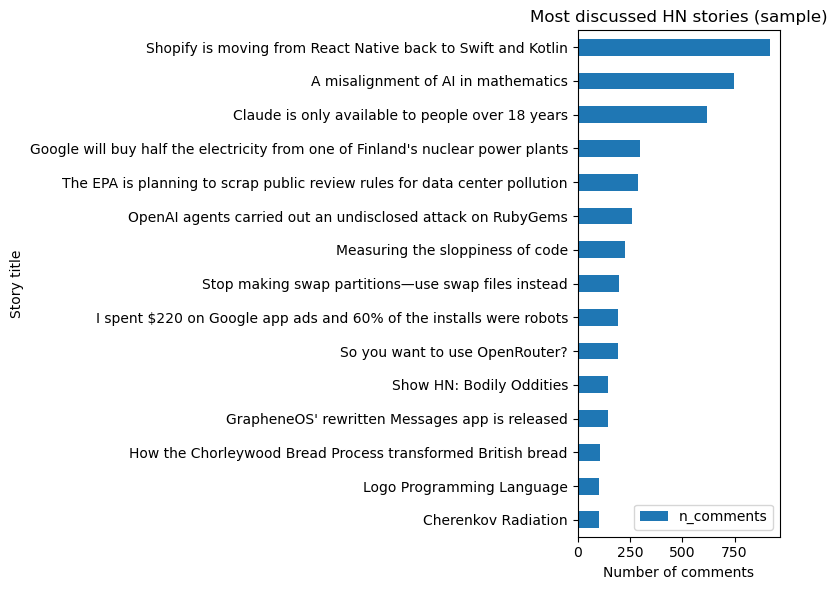

In [60]:
ax = (
    comments_per_story.sort_values('n_comments')
    .tail(15)
    .plot(kind='barh', x='title', y='n_comments', figsize=(8,6))
)
ax.set_xlabel('Number of comments')
ax.set_ylabel('Story title')
ax.set_title('Most discussed HN stories (sample)')
plt.tight_layout()
plt.show()

In [61]:
merged_df['user'].fillna('unknown').value_counts().head(10)

user
Dylan16807         22
embedding-shape    22
simonhamp          21
andai              20
jenders            20
walrus01           19
mitxela            19
vatsachak          19
vesterde           18
SoftTalker         16
Name: count, dtype: int64

<small>This assignment was designed with the assistance of ChatGPT.</small>